# Análisis de Componentes Principales (PCA)
## Fundamentos y Aplicación en Ciencias Marino-Costeras

---

## ¿Qué es PCA?

El **Análisis de Componentes Principales (PCA)** es una técnica de reducción de dimensionalidad que transforma un conjunto de variables posiblemente correlacionadas en un conjunto menor de variables no correlacionadas llamadas **componentes principales**. Cada componente captura la máxima varianza posible del conjunto de datos original.

**Transformación ortogonal:**
$$PC_i = w_{i1} X_1 + w_{i2} X_2 + \cdots + w_{ip} X_p$$

Donde los pesos $w_{ij}$ (loadings) representan la contribución de cada variable original al componente $i$, y los componentes están ordenados decrecientemente por varianza explicada:
$$\text{Var}(PC_1) \geq \text{Var}(PC_2) \geq \cdots \geq \text{Var}(PC_p)$$

---

## Supuestos del Método

| Supuesto | Descripción |
|----------|-------------|
| **Linealidad** | Las relaciones entre variables deben ser lineales |
| **Varianza alta = Estructura** | Se asume que componentes con mayor varianza contienen más información |
| **Ortogonalidad** | Los componentes principales son perpendiculares (no correlacionados entre sí) |
| **Escala uniforme** | Las variables deben estandarizarse antes de PCA cuando tienen diferentes unidades |

---

## Objetivos de Aprendizaje

Al completar este módulo podrás:
- Aplicar PCA para reducción de dimensionalidad en datos ambientales multivariados
- Interpretar los **loadings** (cargas) para identificar qué variables dominan cada componente
- Leer e interpretar un **biplot** que muestra simultáneamente scores y cargas
- Decidir cuántos componentes retener usando el criterio de varianza acumulada (≥ 80%)
- Relacionar los componentes con procesos ecológicos en ecosistemas marinos

---

## Pruebas Estadísticas Clave

- **KMO (Kaiser-Meyer-Olkin):** Mide la adecuación muestral para PCA. KMO ≥ 0.6 indica que PCA es apropiado.
- **Prueba de Bartlett:** Verifica si la matriz de correlación es la identidad (H₀: no hay correlación). Si p < 0.05, existe estructura suficiente para PCA.
- **Scree plot:** Gráfico de varianza explicada por componente; el "codo" indica el número óptimo de componentes.

---

## Aplicaciones Marino-Costeras

- Identificar gradientes ambientales (temperatura, salinidad, nutrientes) que estructuran comunidades de plancton
- Resumir variables oceanográficas en índices interpretables (e.g., componente de productividad vs. componente de mezcla)
- Reducir multicolinealidad antes de regresión múltiple
- Comparar estaciones de muestreo en espacio reducido de componentes principales

---

## Duración Estimada
60-90 minutos


## Marco Teórico: PCA en Detalle

### ¿Por qué estandarizar antes de PCA?

PCA busca los ejes de mayor varianza. Si las variables tienen diferentes escalas (ej. temperatura en °C vs. concentración de nutrientes en μmol/L), las variables con mayor rango dominarán los componentes, sin importar su relevancia ecológica. La estandarización (media=0, desviación=1) garantiza que todas las variables contribuyan equitativamente.

$$z_i = \frac{x_i - \bar{x}}{\sigma}$$

### Cómo se calculan los Componentes Principales

1. **Matriz de covarianza** (o correlación si se estandarizó): $\Sigma = \frac{1}{n-1} X^T X$
2. **Descomposición en valores propios**: $\Sigma = V \Lambda V^T$ donde $V$ contiene los eigenvectores (loadings)
3. **Proyección**: Las puntuaciones (scores) son $T = X \cdot V$

### Interpretación de Loadings y Scores

| Concepto | Qué representa | Rango típico |
|----------|----------------|--------------|
| **Loadings** | Peso/contribución de cada variable original al componente | -1 a +1 |
| **Scores** | Coordenadas de cada observación en el espacio de componentes | Sin límite fijo |
| **Varianza explicada** | Proporción de información total capturada por cada PC | 0% a 100% |

### Criterios para Seleccionar Número de Componentes

- **Criterio del codo** (Scree plot): Retener componentes antes del punto donde la curva se aplana
- **Varianza acumulada**: Retener hasta explicar ≥ 80% de varianza total
- **Valores propios > 1** (Regla de Kaiser): Solo componentes con eigenvalor mayor a 1

### Semáforo de Resultados PCA

| Resultado | Interpretación |
|-----------|----------------|
| KMO ≥ 0.8 | Excelente para PCA |
| KMO 0.6-0.8 | Aceptable para PCA |
| KMO < 0.6 | No recomendado PCA |
| PC1 + PC2 > 80% varianza | Reducción dimensionalidad exitosa |
| PC1 + PC2 < 50% varianza | Considerar más componentes |



Case Use: Analyzing Impact of Environmental Factors on Coral Reef Health
Problem Description:
Coral reefs are delicate ecosystems significantly affected by environmental changes. Factors such as water temperature, pH, and salinity are known to influence coral health. A marine biologist wants to determine the primary environmental factors that are most impactful on coral health to prioritize conservation efforts.

Statistical Technique:
Principal Component Analysis (PCA) will be employed to reduce the dimensionality of the environmental data and identify the principal factors that explain the most variance in coral health.

Hypothesis:
The hypothesis is that a few key environmental variables will be the principal components explaining the majority of the variance in coral reef health.

Simulation Setup:
For this simulation, we'll generate synthetic data for several environmental factors:

Water Temperature (degrees Celsius)
Salinity (PSU - Practical Salinity Units)
pH Levels
Nitrate Concentration (micromoles per liter)
Phosphate Concentration (micromoles per liter)
Coral Health Index (ranging from 0 to 10, where 10 represents optimal health)
The data will simulate measurements taken from 100 different coral reef locations.

Python Code for Simulation and PCA:

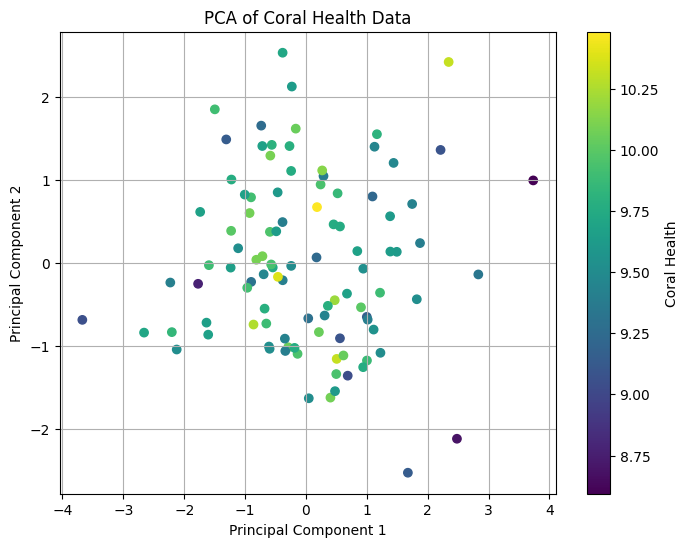

Explained variance by component:  [0.29833524 0.20704092]


In [1]:
# ============================================================
# PASO 1: IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN
# ============================================================
# numpy: operaciones numéricas y generación de datos sintéticos
# pandas: manejo estructurado de datos en formato tabla
# matplotlib: visualizaciones gráficas
# StandardScaler: estandarización de variables (media=0, std=1)
# PCA: algoritmo de Análisis de Componentes Principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ============================================================
# PASO 2: GENERACIÓN DE DATOS SINTÉTICOS
# ============================================================
# Simulamos datos de 5 factores ambientales en 100 sitios de arrecife.
# np.random.seed(42) garantiza reproducibilidad: siempre obtenemos los mismos datos.
np.random.seed(42)
data_size = 100

# Variables ambientales con distribuciones normales realistas para arrecifes coralinos
temperature = np.random.normal(27, 2, data_size)   # Temperatura promedio 27°C (típico del trópico)
salinity    = np.random.normal(35, 0.5, data_size) # Salinidad 35 PSU (agua marina normal)
pH          = np.random.normal(8.1, 0.1, data_size) # pH ligeramente básico (óptimo para corales)
nitrate     = np.random.normal(0.5, 0.1, data_size) # Nitrato bajo (aguas oligotróficas)
phosphate   = np.random.normal(0.2, 0.05, data_size) # Fosfato bajo (típico de arrecifes sanos)

# Índice de salud del coral: disminuye cuando los factores se alejan de sus valores óptimos.
# El ruido gaussiano añade variabilidad realista que no se puede explicar solo con estos factores.
coral_health = 10 - (0.2*abs(temperature-27) + 0.1*abs(salinity-35) +
                     0.3*abs(pH-8.1) + 0.25*abs(nitrate-0.5) +
                     0.15*abs(phosphate-0.2) + np.random.normal(0, 0.3, data_size))

# Organizar en DataFrame para facilitar manipulación y análisis exploratorio
data = pd.DataFrame({
    'Temperature': temperature,
    'Salinity'   : salinity,
    'pH'         : pH,
    'Nitrate'    : nitrate,
    'Phosphate'  : phosphate,
    'Coral Health': coral_health
})

# ============================================================
# PASO 3: ESTANDARIZACIÓN DE VARIABLES
# ============================================================
# PCA es sensible a la escala. Si temperatura varía en ±2°C pero salinidad en ±0.5 PSU,
# temperatura dominaría por tener mayor varianza absoluta, aunque ambas sean igualmente relevantes.
# StandardScaler transforma cada variable a media=0 y desviación estándar=1.
features = ['Temperature', 'Salinity', 'pH', 'Nitrate', 'Phosphate']
x = data.loc[:, features].values
y = data.loc[:, ['Coral Health']].values
x = StandardScaler().fit_transform(x)  # fit calcula media/std; transform aplica la normalización

# ============================================================
# PASO 4: APLICAR PCA
# ============================================================
# n_components=2 retiene solo los 2 primeros componentes principales.
# Estos capturan la mayor proporción de varianza con la menor cantidad de dimensiones.
pca = PCA(n_components=2)
principal_components = pca.fit_transform(x)  # fit encuentra los ejes; transform proyecta los datos

# Crear DataFrame con los scores (posición de cada observación en el espacio PCA)
principal_df = pd.DataFrame(
    data=principal_components,
    columns=['Principal Component 1', 'Principal Component 2']
)

# Unir scores con la variable de salud del coral para colorear el gráfico
final_df = pd.concat([principal_df, data[['Coral Health']]], axis=1)

# ============================================================
# PASO 5: VISUALIZACIÓN — SCATTER PLOT DE SCORES
# ============================================================
# Cada punto representa un sitio de arrecife. El color indica su índice de salud.
# Si los primeros 2 PCs capturan bien la varianza, sitios con salud similar deberían
# agruparse en regiones similares del espacio PCA.
plt.figure(figsize=(8, 6))
sc = plt.scatter(
    final_df['Principal Component 1'],
    final_df['Principal Component 2'],
    c=final_df['Coral Health'],
    cmap='viridis',
    edgecolors='k',
    alpha=0.8,
    s=60
)
plt.xlabel('Componente Principal 1 (mayor varianza)')
plt.ylabel('Componente Principal 2')
plt.colorbar(sc, label='Índice de Salud del Coral')
plt.title('PCA de Factores Ambientales en Arrecifes Coralinos', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

# ============================================================
# PASO 6: VARIANZA EXPLICADA
# ============================================================
# explained_variance_ratio_[i] = fracción de la varianza total explicada por el PC i+1.
# La suma acumulada indica cuánta información del dataset original captura nuestra proyección 2D.
print("Varianza explicada por componente:", pca.explained_variance_ratio_)
print(f"Total varianza explicada por PC1+PC2: {sum(pca.explained_variance_ratio_)*100:.1f}%")
print()
print("Loadings (contribución de cada variable a los componentes):")
loadings_df = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=['PC1', 'PC2']
)
print(loadings_df.round(3))
print()
print("INTERPRETACIÓN: Valores de loading altos (cercanos a ±1) indican que")
print("esa variable tiene fuerte influencia en el componente respectivo.")


Explanation:
In this Python code:

Data Generation: Synthetic data for five environmental factors and coral health is created.
Standardization: The features are standardized to have zero mean and unit variance, which is a requirement for PCA.
PCA Application: PCA is applied to the standardized features to reduce the dimensionality to two principal components.
Visualization: A scatter plot visualizes the two principal components colored by the Coral Health Index to see how well the PCA captures the variability in coral health with respect to environmental conditions.
Variance Explanation: The script ends by printing out the explained variance ratio, which shows the proportion of variance each principal component holds.
This simulation will help identify the major environmental factors affecting coral reef health and guide targeted conservation strategies.

       Temperature    Salinity          pH     Nitrate   Phosphate  \
count   500.000000  500.000000  500.000000  500.000000  500.000000   
mean     27.013676   35.015913    8.110848    0.503319    0.199424   
std       1.962506    0.488999    0.101025    0.098407    0.047978   
min      20.517465   33.651557    7.810374    0.205961    0.049024   
25%      25.599385   34.702354    8.039757    0.438806    0.166963   
50%      27.025594   35.014266    8.111981    0.499109    0.199842   
75%      28.273567   35.325621    8.175474    0.569977    0.233459   
max      34.705463   36.316191    8.360168    0.819311    0.355496   

       Coral Health  
count    500.000000  
mean       9.592948  
std        0.399335  
min        7.828205  
25%        9.357414  
50%        9.606344  
75%        9.857797  
max       10.466713  


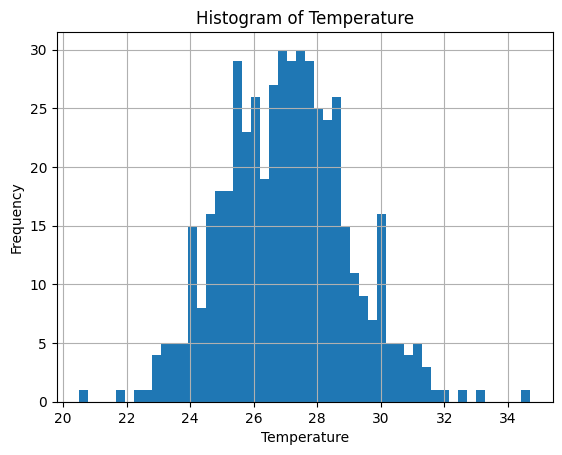

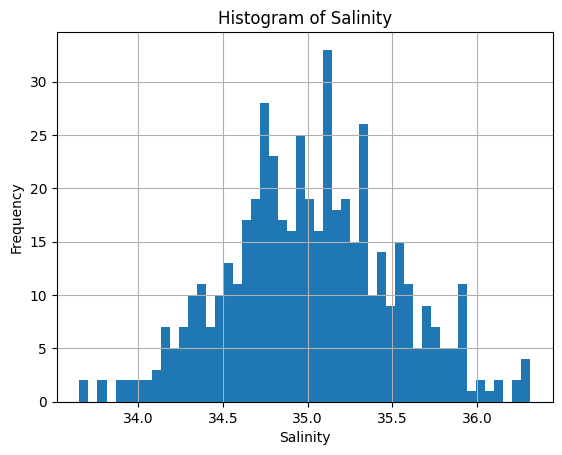

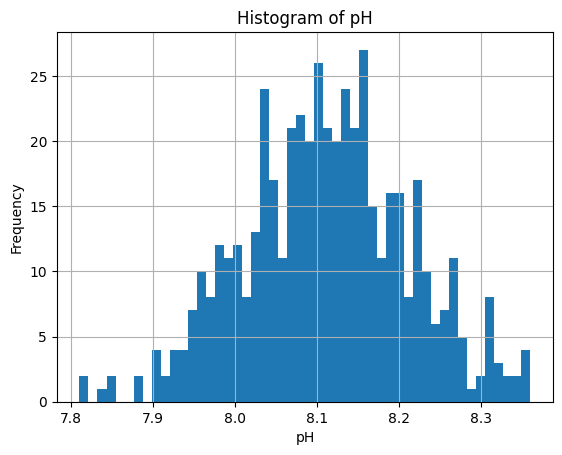

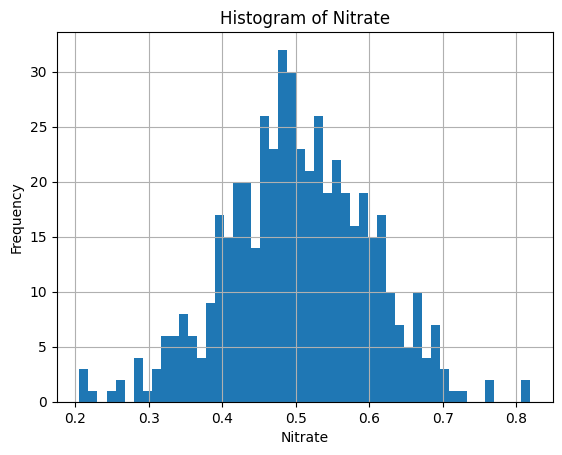

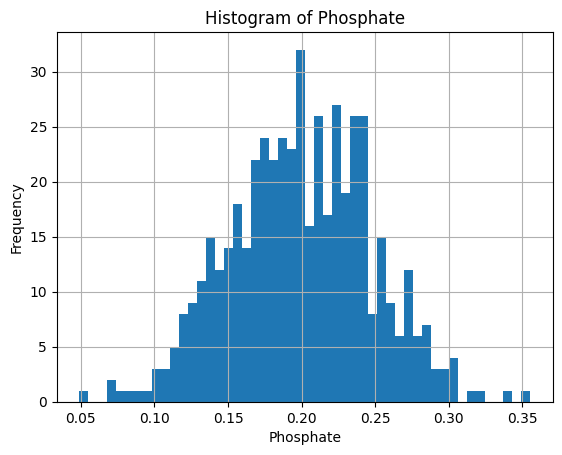

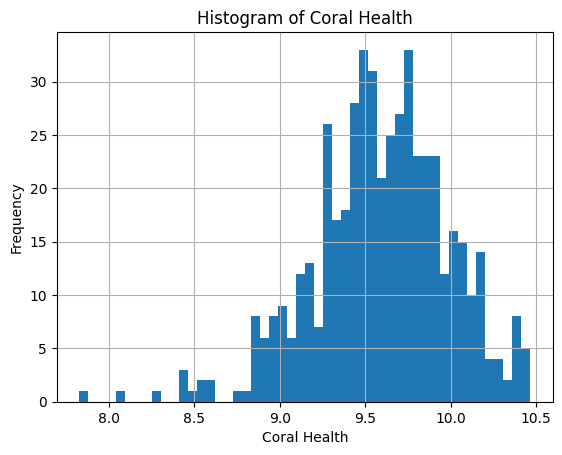

<Figure size 1200x600 with 0 Axes>

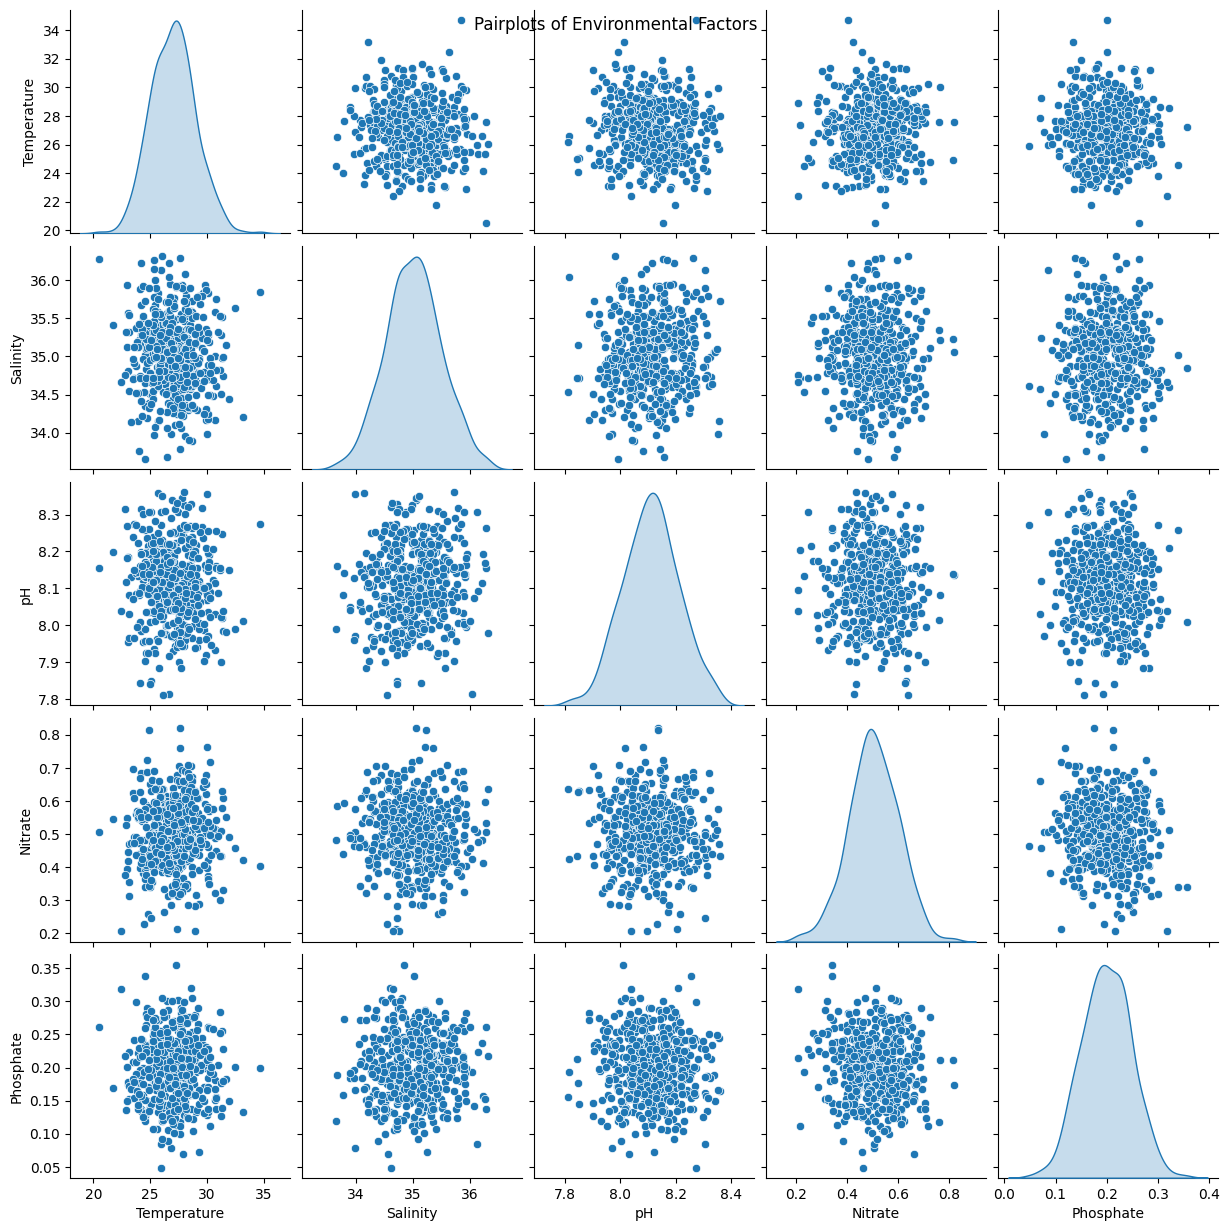

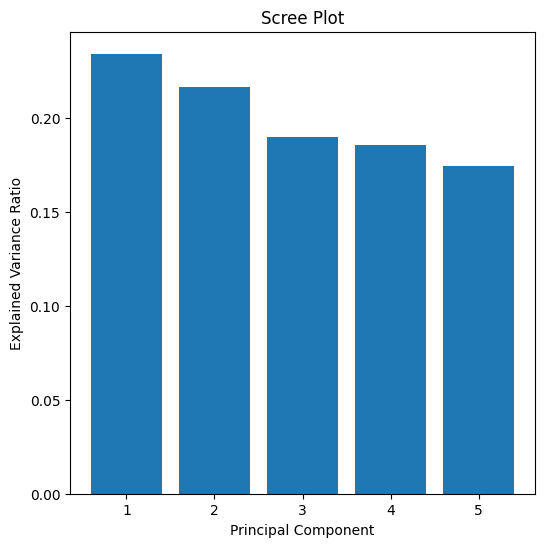

Explained variance by component:  [0.23412906 0.21648436 0.189645   0.18557611 0.17416548]
Correlation matrix: 
              Temperature  Salinity        pH   Nitrate  Phosphate
Temperature     1.000000 -0.075671 -0.057791  0.064140  -0.008269
Salinity       -0.075671  1.000000  0.076038 -0.021578   0.025885
pH             -0.057791  0.076038  1.000000 -0.022057  -0.043433
Nitrate         0.064140 -0.021578 -0.022057  1.000000  -0.087760
Phosphate      -0.008269  0.025885 -0.043433 -0.087760   1.000000


In [2]:
# ============================================================
# ANÁLISIS PCA EXTENDIDO — MUESTRA AMPLIADA Y DIAGNÓSTICO COMPLETO
# ============================================================
# Esta celda amplía el análisis anterior con:
#   1. Mayor tamaño de muestra (500 vs 100) para resultados más estables
#   2. Estadísticas descriptivas para verificar los datos generados
#   3. Histogramas de cada variable para verificar normalidad aproximada
#   4. Pairplot para visualizar correlaciones entre variables
#   5. Scree plot para decidir cuántos componentes retener
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns

# ============================================================
# PASO 1: GENERAR DATOS AMPLIADOS
# ============================================================
# Con n=500 (vs n=100 anterior), las estimaciones de varianza son más precisas
# y el PCA es más estable. Muestras pequeñas pueden producir componentes artificiales.
np.random.seed(42)
data_size = 500

# Variables ambientales de arrecifes coralinos (mismos parámetros que celda anterior)
temperature = np.random.normal(27, 2, data_size)
salinity    = np.random.normal(35, 0.5, data_size)
pH          = np.random.normal(8.1, 0.1, data_size)
nitrate     = np.random.normal(0.5, 0.1, data_size)
phosphate   = np.random.normal(0.2, 0.05, data_size)

# Índice de salud del coral (variable dependiente, no incluida en PCA)
coral_health = 10 - (0.2*abs(temperature-27) + 0.1*abs(salinity-35) +
                     0.3*abs(pH-8.1) + 0.25*abs(nitrate-0.5) +
                     0.15*abs(phosphate-0.2) + np.random.normal(0, 0.3, data_size))

data = pd.DataFrame({
    'Temperature': temperature,
    'Salinity'   : salinity,
    'pH'         : pH,
    'Nitrate'    : nitrate,
    'Phosphate'  : phosphate,
    'Coral Health': coral_health
})

# ============================================================
# PASO 2: ESTADÍSTICAS DESCRIPTIVAS
# ============================================================
# describe() muestra count, mean, std, min, cuartiles y max.
# Verificamos que los rangos sean razonables para datos de arrecifes.
print("Estadísticas Descriptivas del Dataset:")
print(data.describe().round(3))
print()

# ============================================================
# PASO 3: HISTOGRAMAS PARA VERIFICAR NORMALIDAD
# ============================================================
# PCA no requiere normalidad estrictamente, pero distribuciones muy sesgadas
# pueden hacer que un componente capte outliers en lugar de estructura real.
print("Generando histogramas de distribución de cada variable...")
features = ['Temperature', 'Salinity', 'pH', 'Nitrate', 'Phosphate']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for idx, col in enumerate(features):
    axes[idx].hist(data[col], bins=30, color='steelblue', edgecolor='k', alpha=0.8)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frecuencia')
    axes[idx].set_title(f'Distribución: {col}')
    axes[idx].grid(True, alpha=0.3)
axes[5].axis('off')  # Celda vacía del grid
plt.tight_layout()
plt.show()

# ============================================================
# PASO 4: ESTANDARIZACIÓN Y APLICACIÓN DE PCA COMPLETO
# ============================================================
x = data.loc[:, features].values
StandardScaler().fit_transform(x)   # Vista previa (no guarda)
x = StandardScaler().fit_transform(x)  # Escala cada variable a N(0,1)

# PCA sin especificar n_components calcula TODOS los componentes (5 en este caso).
# Esto nos permite ver la varianza total y decidir cuántos retener.
pca = PCA()
principal_components = pca.fit_transform(x)
explained_variance = pca.explained_variance_ratio_  # Fracción de varianza por componente

# ============================================================
# PASO 5: PAIRPLOT — RELACIONES ENTRE VARIABLES ORIGINALES
# ============================================================
# El pairplot muestra scatter plots de cada par de variables y distribuciones en la diagonal.
# Si dos variables muestran correlación lineal, PCA las combinará en un solo componente.
# Variables independientes entre sí aportan componentes separados.
print("Generando pairplot de variables ambientales...")
fig = plt.figure(figsize=(12, 6))
g = sns.pairplot(data, vars=features, diag_kind='kde', plot_kws={'alpha': 0.4})
g.figure.suptitle('Relaciones Entre Variables Ambientales (Pairplot)', y=1.02, fontsize=13)
plt.show()

# ============================================================
# PASO 6: SCREE PLOT — CRITERIO VISUAL PARA NÚMERO DE COMPONENTES
# ============================================================
# El Scree plot grafica la varianza explicada vs. número de componente.
# El "codo" (punto de inflexión) indica cuántos componentes son informativos.
# Componentes después del codo explican varianza residual/ruido.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Varianza individual por componente
axes[0].bar(range(1, len(explained_variance)+1), explained_variance * 100,
            color='steelblue', edgecolor='k', alpha=0.8)
axes[0].set_xlabel('Número de Componente Principal')
axes[0].set_ylabel('Varianza Explicada (%)')
axes[0].set_title('Scree Plot: Varianza por Componente')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(explained_variance):
    axes[0].text(i+1, v*100 + 0.5, f'{v*100:.1f}%', ha='center', fontsize=10)

# Varianza acumulada — línea horizontal en 80% como criterio común
cumvar = np.cumsum(explained_variance) * 100
axes[1].plot(range(1, len(cumvar)+1), cumvar, 'o-', color='coral', linewidth=2, markersize=8)
axes[1].axhline(y=80, color='green', linestyle='--', label='Umbral 80%')
axes[1].axhline(y=90, color='orange', linestyle='--', label='Umbral 90%')
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Varianza Acumulada (%)')
axes[1].set_title('Varianza Acumulada — ¿Cuántos Componentes Retener?')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# PASO 7: REPORTE FINAL
# ============================================================
print("Varianza explicada por componente:")
for i, v in enumerate(explained_variance):
    cumulative = np.sum(explained_variance[:i+1])
    print(f"  PC{i+1}: {v*100:.2f}%  (acumulado: {cumulative*100:.2f}%)")

print()
print("Matriz de Correlación de Variables Originales:")
print(data[features].corr().round(3))
print()
print("GUÍA DE INTERPRETACIÓN:")
print("  - Varianza acumulada > 80% con pocos PCs → PCA muy efectivo")
print("  - Variables con |loading| > 0.5 → contribuyen significativamente al componente")
print("  - Correlaciones altas (> ±0.7) entre variables originales → se fusionarán en PCs")


# Ejercicios para el Estudiante

## Ejercicio 1: PCA en Datos Oceanográficos
Descarga datos oceanográficos de una región marina (temperatura, salinidad, densidad, nutrientes).
Aplica PCA y responde:
- ¿Cuántos componentes explican el 90% de la varianza?
- ¿Cuáles son las variables más importantes en el primer componente principal?
- Visualiza los datos en el espacio de los dos primeros componentes.

## Ejercicio 2: Interpretación de Cargas
Realiza PCA en datos de calidad del agua de diferentes estaciones costeras.
- Calcula y visualiza las cargas (loadings) de cada variable en los componentes.
- ¿Cuál es el patrón de correlación que representa el primer componente?
- Compara las cargas entre diferentes temporadas si los datos lo permiten.

## Ejercicio 3: Comparación de Métodos de Escalado
Aplica PCA a los mismos datos usando:
- Estandarización (StandardScaler)
- Normalización por rango [0,1]
- Sin escalar (si las variables tienen unidades similares)

¿Cómo cambian los resultados? ¿Cuál es el más apropiado para tu conjunto de datos?